# Progetto DIA - A.A 2025/26

Autori: Justin Carideo (justin.carideo@studio.unibo.it), Laura Bertozzi (laura.bertozzi5@studio.unibo.it)

# Setup

In [173]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
import seaborn as sns
import kaggle
import os
import os.path
from sklearn.model_selection import KFold, StratifiedKFold, RandomizedSearchCV
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier


sns.set_theme(style="whitegrid")

Importiamo i dataset presi dal sito https://www.kaggle.com. Questi due dataset fanno riferimento a dati in ambito agricolo, in particolare:
1) **Crop Dataset** -> dataset incentrato su aspetti ambientali per individuare il tipo di coltura dato il tipo di terreno e nutrienti presenti (https://www.kaggle.com/datasets/varshitanalluri/crop-recommendation-dataset)
2) **Fertilizer DataSet** -> dataset incentrato sullo stesso campo ma che vuole individuare il tipo di fertilizzante dato il tipo di terreno e la coltura presente. (https://www.kaggle.com/datasets/nishchalchandel/fertilizer-recommendation)

In [174]:
CROP_DATASET_ID = "varshitanalluri/crop-recommendation-dataset"
FERTILIZER_DATASET_ID = "nishchalchandel/fertilizer-recommendation"

BASE_DOWNLOAD_DIR = "data"

CROP_DATASET_DIR = os.path.join(BASE_DOWNLOAD_DIR, "dataset_1")
FERTILIZER_DATASET_DIR = os.path.join(BASE_DOWNLOAD_DIR, "dataset_2")

os.makedirs(BASE_DOWNLOAD_DIR, exist_ok=True) # crea la directory se non esiste


def download_kaggle_dataset(dataset_id, dataset_path):
    os.makedirs(dataset_path, exist_ok=True)
    if not os.listdir(dataset_path):
        print(f"Download {dataset_id} in {dataset_path}")
        kaggle.api.dataset_download_files(
            dataset_id,
            path=dataset_path,
            unzip=True
        )
    else:
        print(f"Dataset already in specified path")

download_kaggle_dataset(CROP_DATASET_ID, CROP_DATASET_DIR)
download_kaggle_dataset(FERTILIZER_DATASET_ID, FERTILIZER_DATASET_DIR)

CROP_DATASET_PATH = os.path.join(CROP_DATASET_DIR, "Crop_recommendation.csv")
FERTILIZER_DATASET_PATH = os.path.join(FERTILIZER_DATASET_DIR, "fertilizer_recommendation_dataset.csv")

Dataset already in specified path
Dataset already in specified path


Creiamo i dataframe di entrambi i dataset:

In [175]:
crop_df = pd.read_csv(CROP_DATASET_PATH)
fertilizer_df = pd.read_csv(FERTILIZER_DATASET_PATH)

Ora che abbiamo ottenuto i dataset dobbiamo decidere che modello attuare su questi dataset e visto che non hanno indici univoci per riga possiamo attuare una **classificazione** per la predizione di colture e fertilizzanti. In particolare potremmo ragionare con una sorta di *pipeline* dove i dati di entrambi vengono utilizzati per ottenere una classificazione della coltura desiderata date le informazioni relative al terreno e utilizzare i dati ottenuti per calcolare anche il tipo di fertilizzante da attuare.

Questa è una analisi a priori, una volta svolta l'*analisi esplorativa* si potrà procedere con la costruzione del modello.


# Analisi Esplorativa

In [176]:
crop_df.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


In [177]:
fertilizer_df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [178]:
crop_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [179]:
fertilizer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   str    
 9   Crop         3100 non-null   str    
 10  Fertilizer   3100 non-null   str    
 11  Remark       3100 non-null   str    
dtypes: float64(8), str(4)
memory usage: 290.8 KB


In [180]:
crop_df.describe()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [181]:
fertilizer_df.describe()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
count,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000
mean,27.271096,0.600763,111.024949,6.379775,61.278480,69.582850,69.721167,1.474325
std,9.114450,0.144947,77.151880,0.957103,10.186410,42.226712,35.304241,0.698300
min,4.011486,0.227436,-85.709593,3.448974,35.527718,-37.649739,-20.509108,-0.280560
25%,22.408505,0.493595,61.283985,5.860489,54.835715,43.039260,49.992405,0.956401
50%,26.132938,0.599520,96.485935,6.337308,59.429649,58.205269,58.710808,1.463357
75%,29.987887,0.708575,147.619401,6.899739,65.792790,86.108983,76.318626,2.003534
max,56.653592,0.972361,411.955947,9.562341,98.581039,177.314481,161.067982,3.241984


Osserviamo ora quali colture vengono prese in considerazione dai dataset.

Poniamo quindi le stringhe dei nomi delle colture in minuscolo ed eliminiamo eventuali spazi, per poi cercare corrispondenze tra di esse.

In [182]:
crops_fertilizer = fertilizer_df["Crop"].unique()
crops_fertilizer = [x.lower() and x.strip() for x in crops_fertilizer]
print(crops_fertilizer)

['rice', 'wheat', 'Mung Bean', 'Tea', 'millet', 'maize', 'Lentil', 'Jute', 'Coffee', 'Cotton', 'Ground Nut', 'Peas', 'Rubber', 'Sugarcane', 'Tobacco', 'Kidney Beans', 'Moth Beans', 'Coconut', 'Black gram', 'Adzuki Beans', 'Pigeon Peas', 'Chickpea', 'banana', 'grapes', 'apple', 'mango', 'muskmelon', 'orange', 'papaya', 'pomegranate', 'watermelon']


In [183]:
crops_crop = crop_df["Crop"].unique()
crops_crop = [x.lower() and x.strip() for x in crops_crop]
print(crops_crop)

['Rice', 'Maize', 'ChickPea', 'KidneyBeans', 'PigeonPeas', 'MothBeans', 'MungBean', 'Blackgram', 'Lentil', 'Pomegranate', 'Banana', 'Mango', 'Grapes', 'Watermelon', 'Muskmelon', 'Apple', 'Orange', 'Papaya', 'Coconut', 'Cotton', 'Jute', 'Coffee']


In [184]:
common = list(set(crops_fertilizer) & set(crops_crop))
print("Common elements:", common)
difference = list(set(crops_crop) - set(common))
print("Elements in crop but not in fertilizer:", difference)

print("Number of common elements:", len(common))
print("Number of elements in crop:", len(crops_crop))

Common elements: ['Cotton', 'Coffee', 'Coconut', 'Lentil', 'Jute']
Elements in crop but not in fertilizer: ['ChickPea', 'MungBean', 'Banana', 'MothBeans', 'Muskmelon', 'Watermelon', 'Pomegranate', 'Orange', 'KidneyBeans', 'PigeonPeas', 'Mango', 'Blackgram', 'Rice', 'Grapes', 'Apple', 'Papaya', 'Maize']
Number of common elements: 5
Number of elements in crop: 22


Notiamo che le colture di `crop_df` rientrano perfettamente nelle colture di `fertilizer_df`. Di conseguenza possiamo portarle allo stesso formato, poi effettuare un join.

In [185]:
def clean_crop_name(name):
    return str(name).lower().replace(" ", "")

In [186]:
crop_df["Crop"] = crop_df["Crop"].map(clean_crop_name)

In [187]:
fertilizer_df["Crop"] = fertilizer_df["Crop"].map(clean_crop_name)

In [188]:
common_crops = set(fertilizer_df["Crop"]).intersection(set(crop_df["Crop"]))
print(common_crops)
print(f"Common crops = {len(common_crops)}")

{'pomegranate', 'papaya', 'mango', 'blackgram', 'pigeonpeas', 'mothbeans', 'apple', 'watermelon', 'jute', 'lentil', 'muskmelon', 'mungbean', 'kidneybeans', 'grapes', 'banana', 'cotton', 'coconut', 'maize', 'rice', 'coffee', 'orange', 'chickpea'}
Common crops = 22


### Osservazione dei campioni mediante diagrammi



Innanzitutto analizziamo le variabili prese in considerazione dai due dataset, ponendo particolare attenzione su quelle in comune.

In [189]:
crop_keys = set(crop_df.keys())
fertilizer_keys = set(fertilizer_df.keys())


print("variabili di \"crop_df\":", list(crop_keys))
print("numero di variabili di \"crop_df\":", len(crop_keys))
print("\nvariabili di \"fertilizer_df\":", list(fertilizer_keys))
print("numero di variabili di \"fertilizer_df\":", len(fertilizer_keys))

common_keys = list(set(crop_keys) & set(fertilizer_keys))
print("\nvariabili comuni:", common_keys)
print("numero di variabili comuni:", len(common_keys))

different_a = list(set(fertilizer_keys) - set(common_keys))
different_b = list(set(crop_keys) - set(common_keys))
different_keys = list(set(crop_keys) ^ set(fertilizer_keys))
print("\nvariabili diverse:", different_keys)
print("numero di variabili diverse:", len(different_keys))

variabili di "crop_df": ['Nitrogen', 'pH_Value', 'Crop', 'Phosphorus', 'Humidity', 'Potassium', 'Temperature', 'Rainfall']
numero di variabili di "crop_df": 8

variabili di "fertilizer_df": ['Moisture', 'PH', 'Nitrogen', 'Crop', 'Phosphorous', 'Fertilizer', 'Soil', 'Carbon', 'Rainfall', 'Temperature', 'Potassium', 'Remark']
numero di variabili di "fertilizer_df": 12

variabili comuni: ['Crop', 'Nitrogen', 'Rainfall', 'Potassium', 'Temperature']
numero di variabili comuni: 5

variabili diverse: ['Moisture', 'PH', 'pH_Value', 'Phosphorus', 'Phosphorous', 'Fertilizer', 'Soil', 'Humidity', 'Carbon', 'Remark']
numero di variabili diverse: 10


Tra le variabili diverse notiamo che tre di esse differiscono solo nel nome, ossia:
* Humidiy e Moisture
* PH e pH_Value
* Phosphorous e Phosphorus

Le restanti quattro rappresentano parametri effettivamente differenti:
* Soil
* Carbon
* Fertilizer (incognita del fertilizer dataset)
* Remark (che ignoriamo per il momento)

Notiamo come alcuni parametri non facciano riferimento alla stessa scala(i.e. humidity -> in percentuale (72%), Moisture -> in proporzione (0.72)). In compenso, per quanto riguarda il resto:
* Temperature -> °C
* Nitrogen, Phosphorous, Carbon, Potassium -> mg/kg
* pH -> misura adimensionale standard (da 0 a 14)
* Rainfall -> mm

In [190]:
map_names = {
    "Moisture": "Humidity",
    "PH" : "pH_Value",
    "Phosphorous" : "Phosphorus"
}

fertilizer_df = fertilizer_df.rename(columns=map_names)
fertilizer_df["Humidity"] = fertilizer_df["Humidity"] * 100 # Per evitare problemi con la divisione

Distribuzione delle Colture:

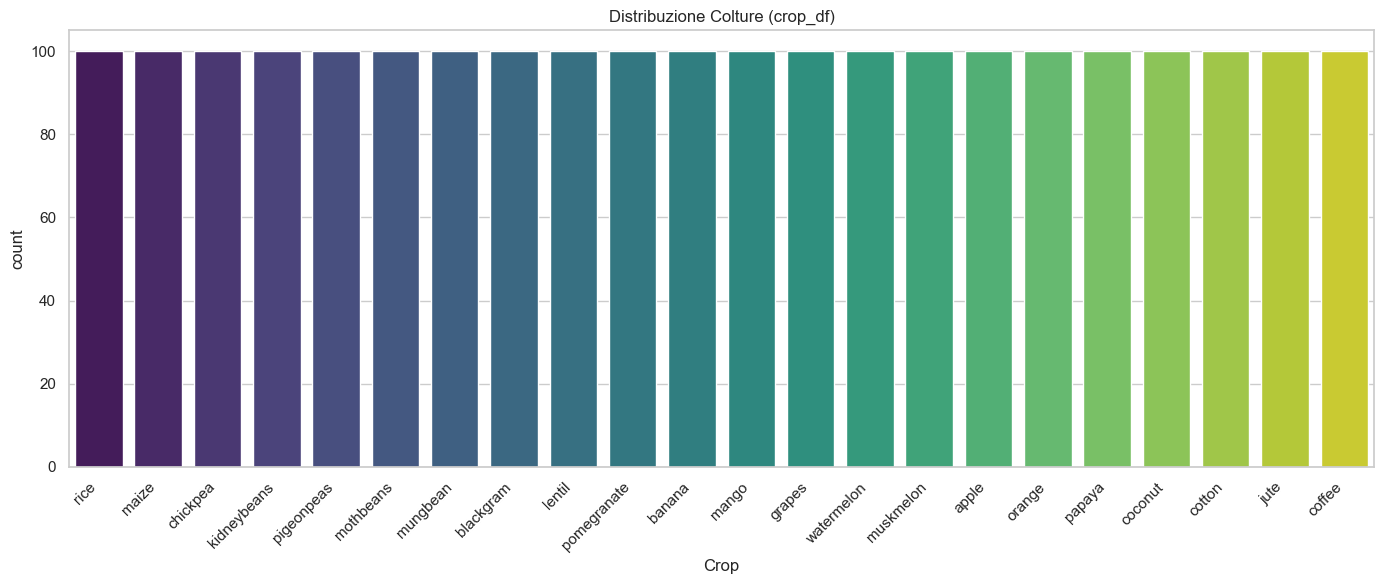

In [191]:
plt.figure(figsize=(14, 6))
sns.countplot(data=crop_df, x='Crop', hue='Crop', palette='viridis', order=crop_df["Crop"].value_counts().index)
plt.title("Distribuzione Colture (crop_df)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

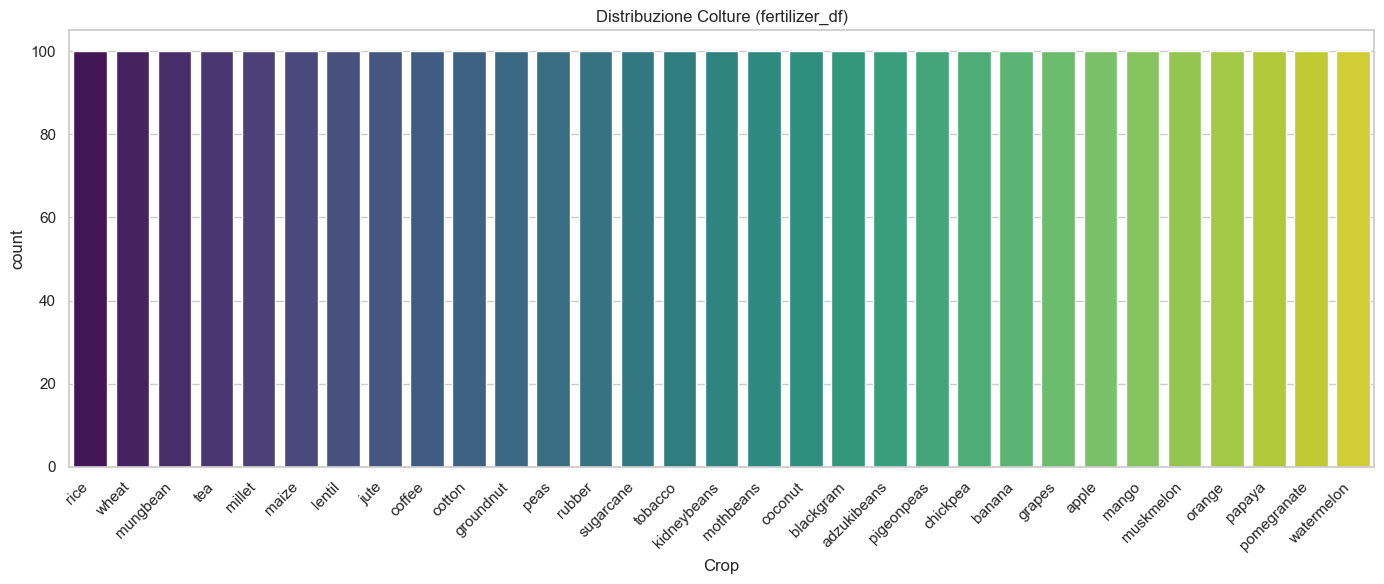

In [192]:
plt.figure(figsize=(14, 6))
sns.countplot(data=fertilizer_df, x='Crop', hue='Crop', palette='viridis', order=fertilizer_df["Crop"].value_counts().index)
plt.title("Distribuzione Colture (fertilizer_df)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Notiamo come entrambi i dataset presentino 100 campioni per coltura.

Definiamo una funzione per fare il plot di tutti quanti i parametri chimici che andremmo ad analizzare

In [ ]:
def plot_chemicals(chemical):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(crop_df[chemical], kde=True, color='blue', ax=axes[0])
    axes[0].set_title(chemical + ' crop_df', fontsize=12)
    axes[0].set_xlabel(chemical)

    sns.histplot(fertilizer_df[chemical], kde=True, color='red', ax=axes[1])
    axes[1].set_title(chemical + ' fertilizer_df', fontsize=12)
    axes[1].set_xlabel(chemical)

Valori di umidità rilevati:

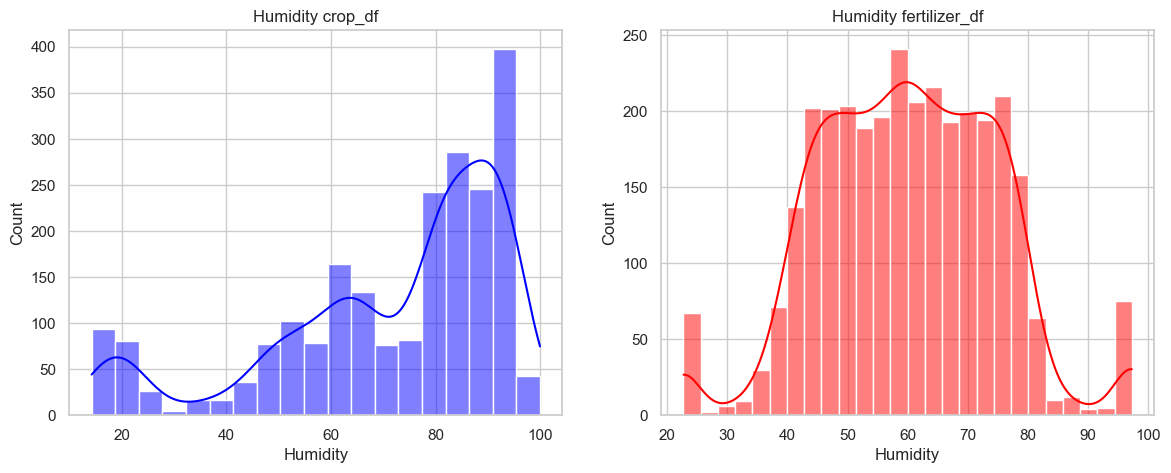

In [194]:
plot_chemicals('Humidity')

Temperature misurate:

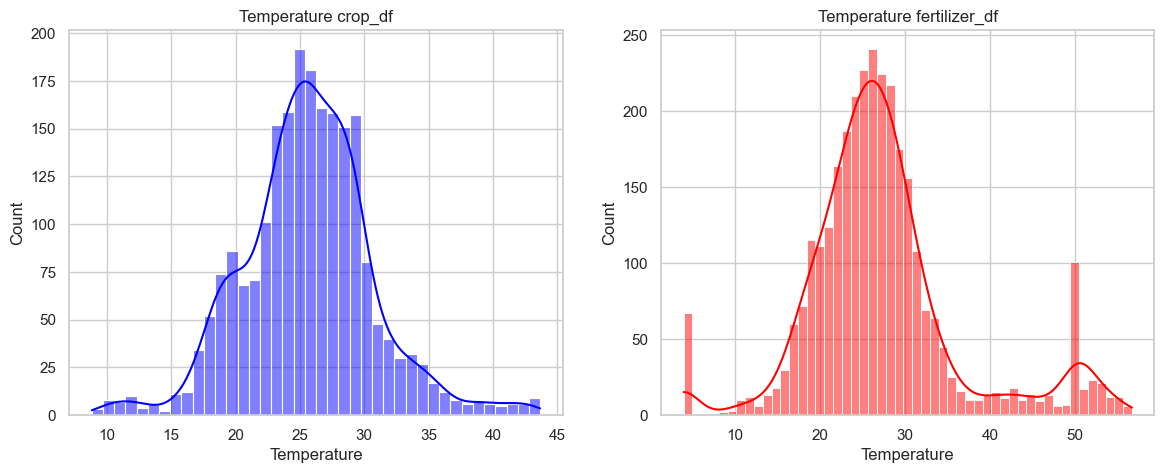

In [195]:
plot_chemicals('Temperature')

Precipitazioni misurate: 

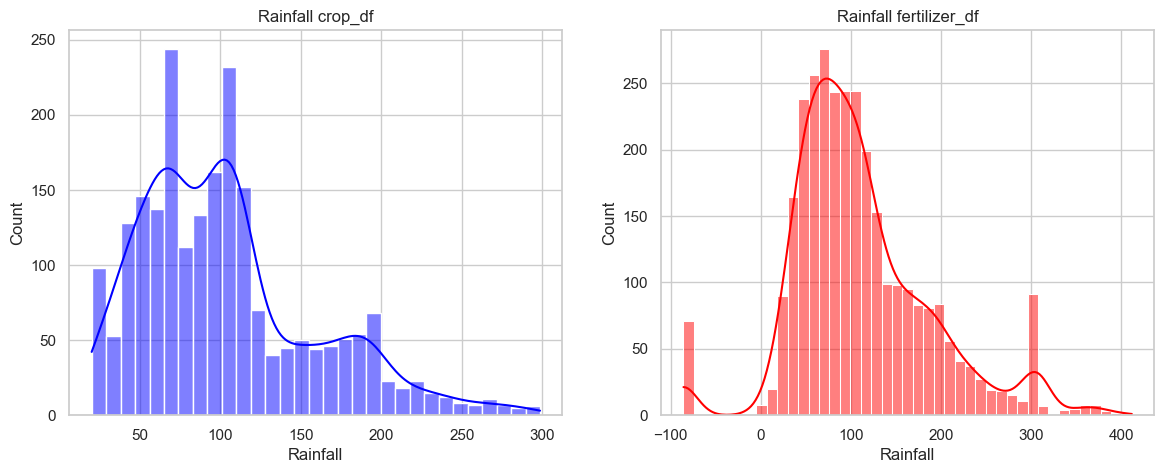

In [196]:
plot_chemicals('Rainfall')

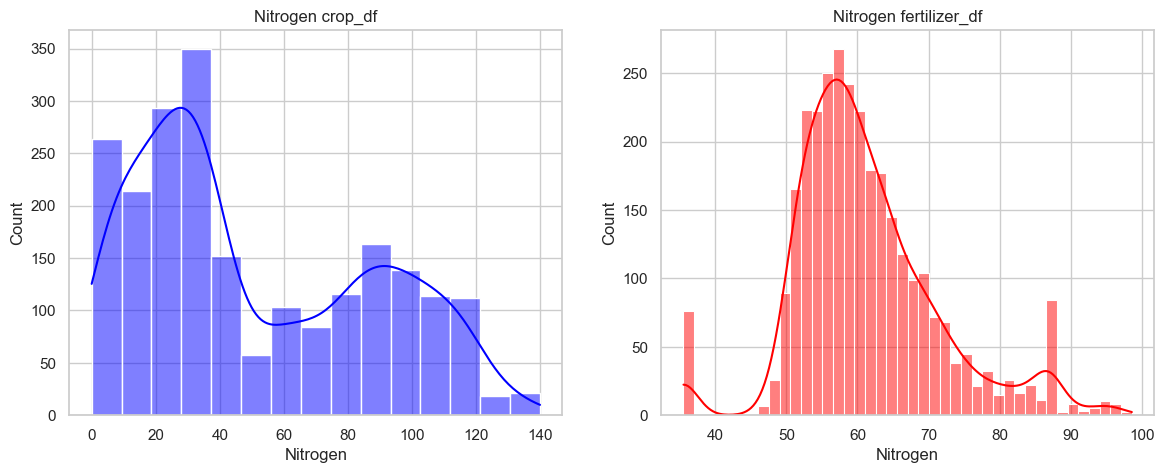

In [ ]:
plot_chemicals('Nitrogen')

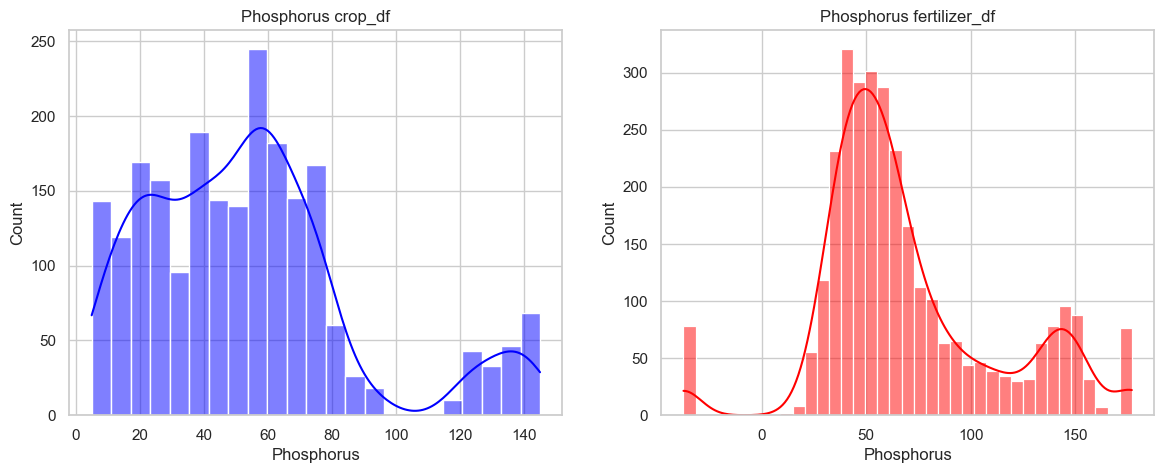

In [198]:
plot_chemicals('Phosphorus')

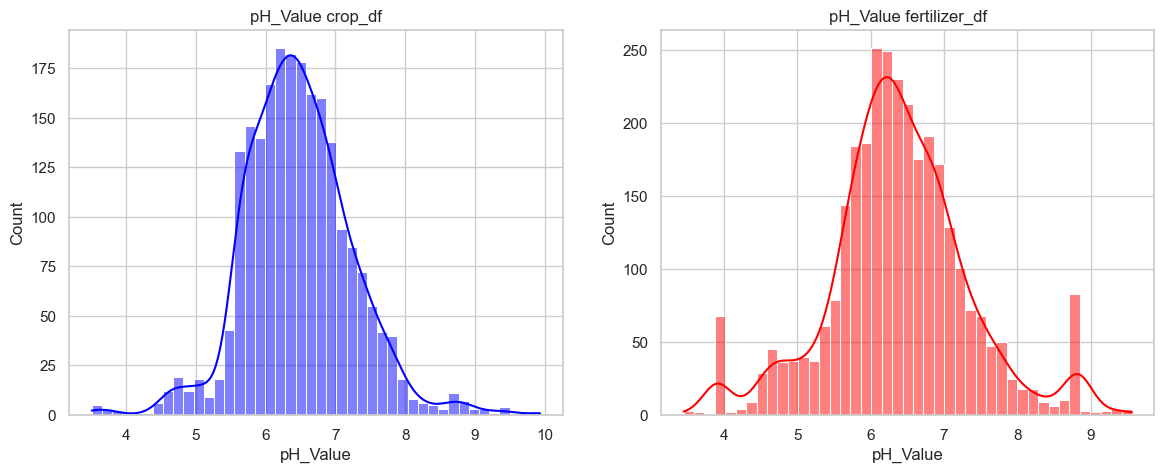

In [201]:
plot_chemicals('pH_Value')

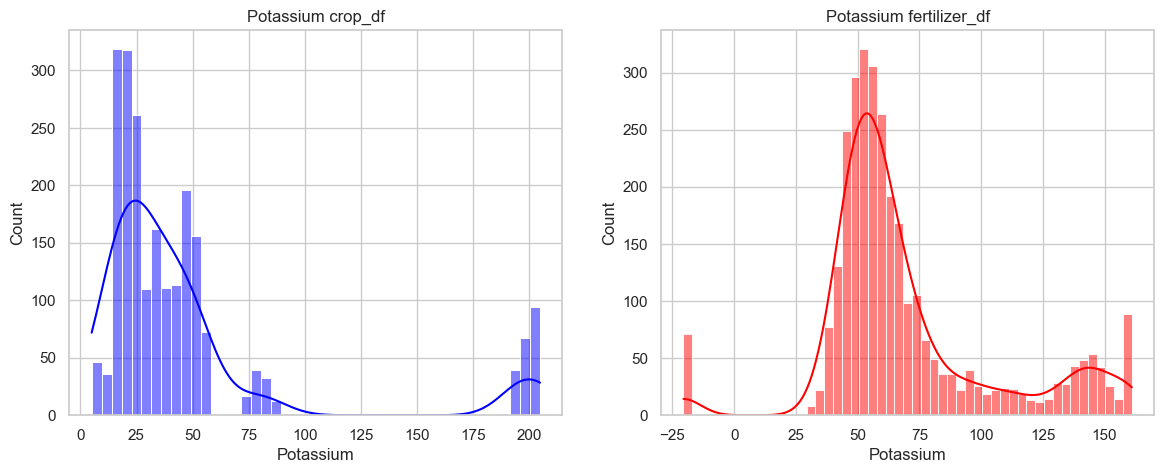

In [202]:
plot_chemicals('Potassium')

Notiamo che c'è una incoerenza con il dataset `fertilizer_df` e che i parametri `Rainfall`, `Potassium`. `Carbon` misurano valori negativi. Essendo una misurazione delle precipitazioni in mm, non è possibile che siano valori negativi. Per tanto abbiamo deciso di mantenere una certa coerenza con i dati e li abbiamo portati a zero:

In [ ]:
fertilizer_df['Potassium'] = fertilizer_df['Potassium'].clip(lower=0)
fertilizer_df['Carbon'] = fertilizer_df['Carbon'].clip(lower=0)
fertilizer_df['Rainfall'] = fertilizer_df['Rainfall'].clip(lower=0)

### Correlazione tra variabili

Analizziamo la correlazione tra umidità e precipitazioni mediante coefficiente di Pearsonn.

Correlation between Humidity and Rainfall in crop_df: 0.17
Correlation between Moisture and Rainfall in fertilizer_df: -0.12


Text(0, 0.5, 'Rainfall (mm)')

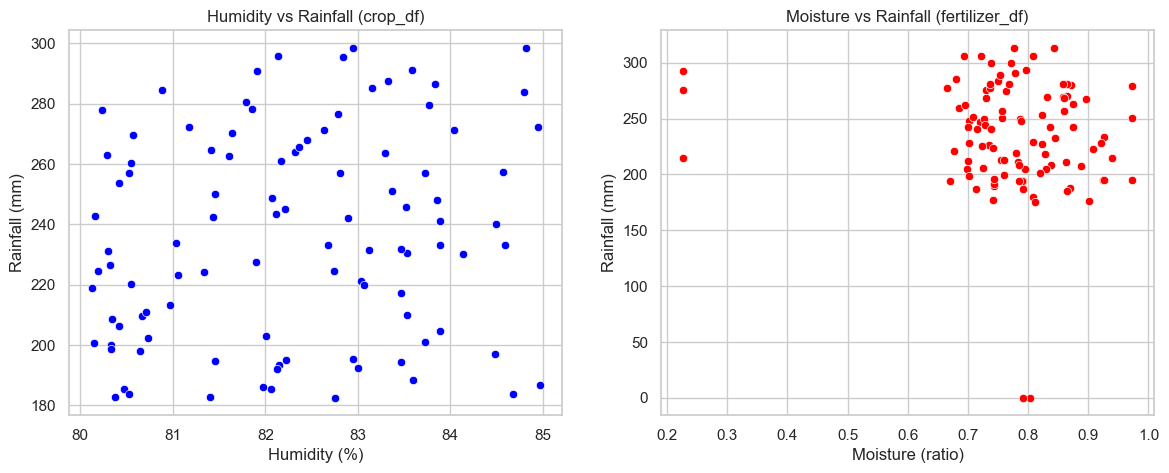

In [ ]:
rice_crop = crop_df[crop_df["Crop"] == "rice"]
rice_fertilizer = fertilizer_df[fertilizer_df["Crop"] == "rice"]
hum_rain_corr_crop = rice_crop["Humidity"].corr(rice_crop["Rainfall"])
hum_rain_corr_fertilizer = rice_fertilizer["Moisture"].corr(rice_fertilizer["Rainfall"])

print(f"Correlation between Humidity and Rainfall in crop_df: {hum_rain_corr_crop:.2f}")
print(f"Correlation between Moisture and Rainfall in fertilizer_df: {hum_rain_corr_fertilizer:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x = rice_crop["Humidity"], y = rice_crop["Rainfall"], color='blue', ax=axes[0])
axes[0].set_title('Humidity vs Rainfall (crop_df)', fontsize=12)
axes[0].set_xlabel('Humidity (%)')
axes[0].set_ylabel('Rainfall (mm)')

sns.scatterplot(x = rice_fertilizer["Moisture"], y = rice_fertilizer["Rainfall"], color='red', ax=axes[1])
axes[1].set_title('Moisture vs Rainfall (fertilizer_df)', fontsize=12)
axes[1].set_xlabel('Moisture (ratio)')
axes[1].set_ylabel('Rainfall (mm)')


Notiamo come non vi sia correlazione tra le due variabili, probabilmente perchè il range dell'umidità è ristretto e perchè la relazione non è lineare. Tentiamo ora la stessa analisi con il coefficiente di Spearman.

Correlation between Humidity and Rainfall in crop_df: 0.17
Correlation between Moisture and Rainfall in fertilizer_df: -0.13


Text(0, 0.5, 'Rainfall (mm)')

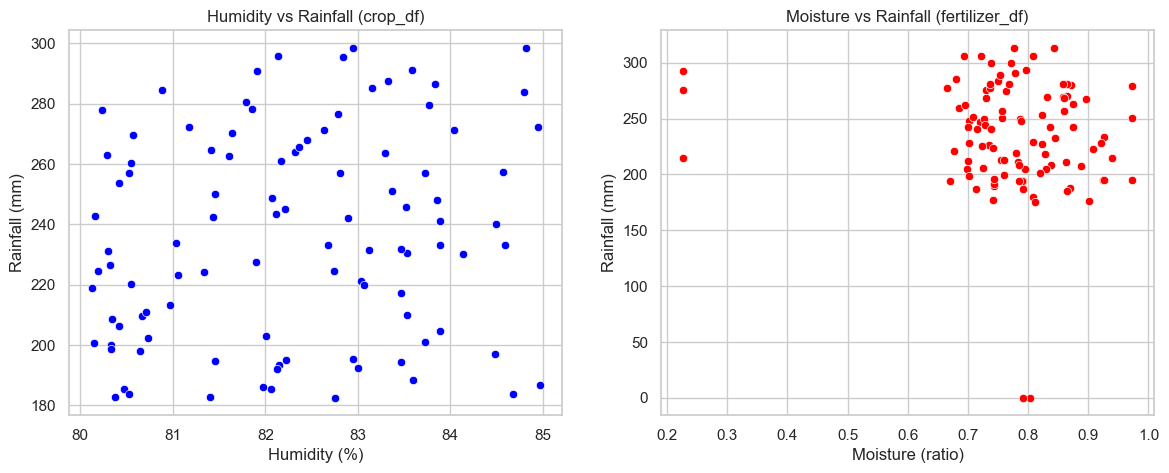

In [ ]:
rice_crop = crop_df[crop_df["Crop"] == "rice"]
rice_fertilizer = fertilizer_df[fertilizer_df["Crop"] == "rice"]
hum_rain_corr_crop = rice_crop["Humidity"].corr(rice_crop["Rainfall"], method='spearman')
hum_rain_corr_fertilizer = rice_fertilizer["Moisture"].corr(rice_fertilizer["Rainfall"], method='spearman')

print(f"Correlation between Humidity and Rainfall in crop_df: {hum_rain_corr_crop:.2f}")
print(f"Correlation between Moisture and Rainfall in fertilizer_df: {hum_rain_corr_fertilizer:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x = rice_crop["Humidity"], y = rice_crop["Rainfall"], color='blue', ax=axes[0])
axes[0].set_title('Humidity vs Rainfall (crop_df)', fontsize=12)
axes[0].set_xlabel('Humidity (%)')
axes[0].set_ylabel('Rainfall (mm)')

sns.scatterplot(x = rice_fertilizer["Moisture"], y = rice_fertilizer["Rainfall"], color='red', ax=axes[1])
axes[1].set_title('Moisture vs Rainfall (fertilizer_df)', fontsize=12)
axes[1].set_xlabel('Moisture (ratio)')
axes[1].set_ylabel('Rainfall (mm)')

Il risultato è pressochè identico, confermando che tra le due variabili Humidity/Moisture e Rainfall non c'è correlazione.

### Mappatura variabili ad un formato comune

In [ ]:
fertilizer_df.head()

,Temperature,Humidity,Rainfall,pH_Value,Nitrogen,Phosphorus,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,72.589298,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,72.195809,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,68.575095,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,75.509467,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,73.067235,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [ ]:
crop_df.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Prima di continuare dobbiamo vedere se effettivamente i dati sono compatibili tra loro, ovvero che dati i due dataset possiamo avere un modello che ha una precisione nell'individuare la stessa classe nonostante due dataset differenti. Come è possibile intuire, un dataset sarà utilizzato come *train set* e l'altro come *test set*.

In [ ]:
common_crops = set(crop_df['Crop']).intersection(set(fertilizer_df['Crop']))
filtered_crop = crop_df[crop_df['Crop'].isin(common_crops)]
filtered_fert = fertilizer_df[fertilizer_df['Crop'].isin(common_crops)]

column_names = ["Temperature", "Humidity", "Rainfall", "pH_Value", "Nitrogen", "Phosphorus", "Potassium"]

X_train_cross = filtered_crop[column_names]
y_train_cross = filtered_crop['Crop']

X_test_cross = filtered_fert[column_names]
y_test_cross = filtered_fert['Crop']

# 5. Addestramento e Test
test_model = RandomForestClassifier(random_state=42)
test_model.fit(X_train_cross, y_train_cross)

intersected_prediction = test_model.predict(X_test_cross)
accuracy = accuracy_score(y_test_cross, intersected_prediction)

print(f"Accuratezza: {accuracy * 100:.2f}%")

Accuratezza: 11.82%


In [ ]:
column_names = ["Temperature", "Humidity", "Rainfall", "pH_Value", "Nitrogen", "Phosphorus", "Potassium", "Crop"]

merged_df = pd.concat([
    fertilizer_df[column_names],
    crop_df[column_names]],
    axis=0,
    join='outer',
    ignore_index=True
)

merged_df.describe()

,Temperature,Humidity,Rainfall,pH_Value,Nitrogen,Phosphorus,Potassium
count,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000
mean,26.584176,64.810676,109.036633,6.417011,56.825904,62.849969,61.041465
std,7.738820,18.977798,66.335683,0.886707,25.577369,39.474324,43.212749
min,4.011486,14.258040,0.000000,3.448974,0.000000,-37.649739,0.000000
25%,22.568594,51.613282,63.159160,5.906321,43.000000,38.938175,36.000000
50%,25.880595,65.021032,95.838012,6.379491,57.932264,55.806835,51.379149
75%,29.221322,79.927009,139.651522,6.907896,68.606625,75.000000,67.661779
max,56.653592,99.981876,411.955947,9.935091,140.000000,177.314481,205.000000


# Addestramento dei modelli
Una volta estratte le feature più importanti possiamo passare al tipo di modello che vogliamo addestrare.

## Modello 1
Il primo modello sarà un modello di *classificazione* per la previsione del parametro `Crop` attraverso degli **alberi di classificazione**, in particolare alleniamo due modelli:
- uno che userà `RandomForestClassifier`, che utilizza *Random Forest*
- uno che userà `xgboost`, che utilizza *Gradient Boosting*

In [ ]:
y = merged_df['Crop']
X = merged_df.drop('Crop', axis=1)

### Random Forest

In [ ]:
def train_random_forest(X, y, title) :
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

    print(f"Accuracy: {accuracy}")

    plt.figure(figsize=(16, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=rf_model.classes_,
                yticklabels=rf_model.classes_)
    plt.title(f"Heatmap con Random Forest - Predizione {title}")
    plt.xlabel(f"{title} predetto")
    plt.ylabel(f"{title} corretto")
    plt.xticks(rotation=45, ha='right')
    plt.show()

    return rf_model


Accuracy: 0.7559748427672957


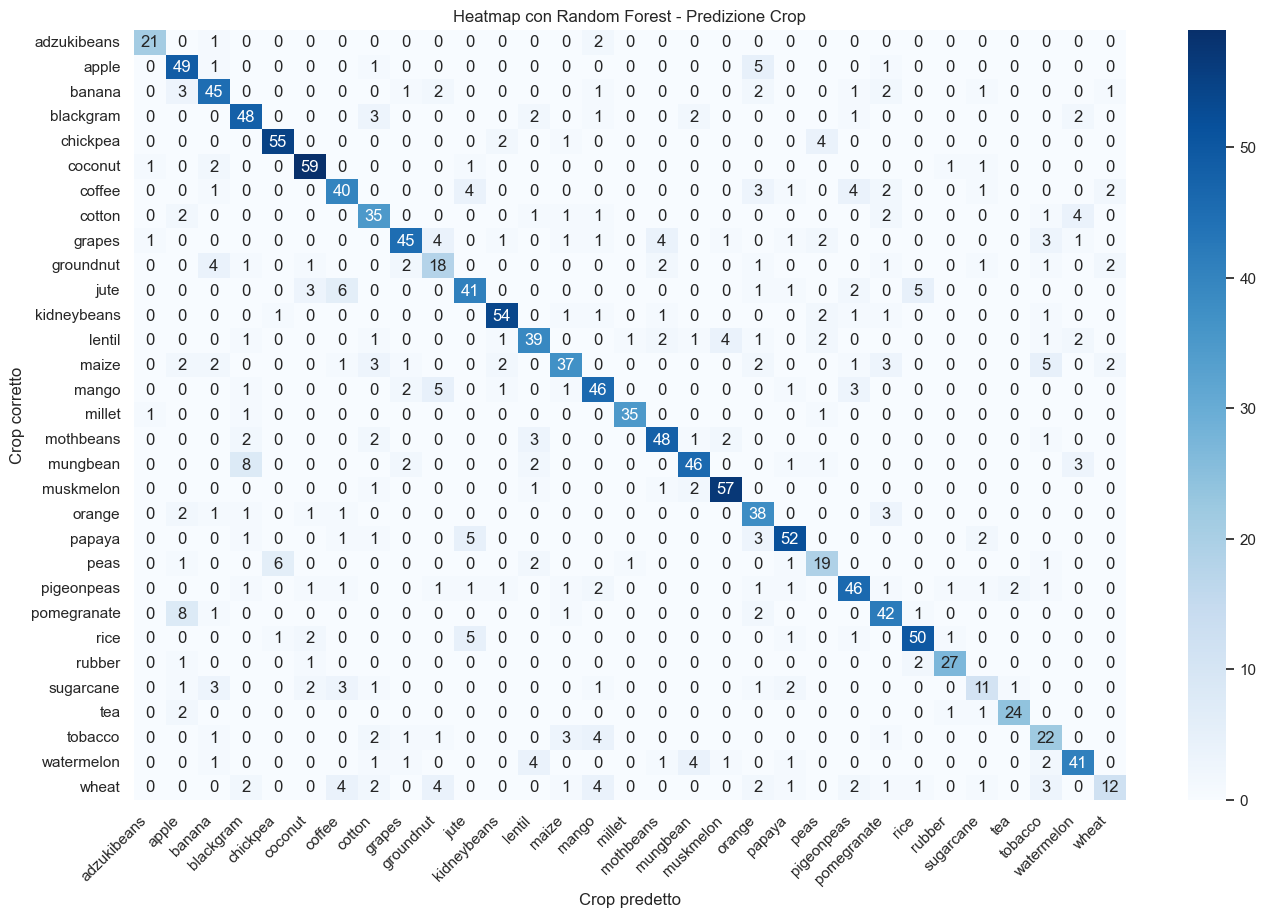

In [ ]:
rf_model = train_random_forest(X, y, "Crop")

Possiamo vedere che l'accuratezza dei dati è del ~75.6%. Questo ci permette di dire che la previsione è già buona di per sè, tuttavia ci sono dei valori da notare nella heatmap, in particolare alcuni errori fatti dal modello:
- `mungbean` -> `blackgram` sono stati confusi diverse volte quando si doveva prevedere `mungbean`, lo stesso vale per `pomegranate` -> `apple`
- `wheat` e `sugarcane` sono stati confusi con altre piante in diversi casi
Questo può essere indice del fatto che alcune piante hanno **esigenze nutrizionali in comune**, quindi è facile aspettarsi che abbiano anche caratteristiche comuni.

Proviamo a migliorare i parametri con **Stratified KFold Cross Validation**:

In [ ]:
def BestParams(n_estimators, max_depth, min_samples_split, min_samples_leaf):
    # Parametri da esplorare
    param_grid = {
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf
    }

    rf_base = RandomForestClassifier(random_state=42)

    validation_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rf_random = RandomizedSearchCV(
        estimator=rf_base,
        param_distributions=param_grid,
        n_iter=20,
        cv=validation_stratified,
        scoring='accuracy',
        verbose=2,
        random_state=42,
        n_jobs=-1
    )

    rf_random.fit(X, y)

    return rf_random.best_params_, rf_random.best_score_

In [ ]:
bestParams, bestScore = BestParams([50, 100, 200, 300], [None, 10, 20, 30, 40], [2, 5, 10], [1, 2, 4])
print(f"Best parameters: {bestParams}")
print(f"Best score: {bestScore * 100:.2f}%")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 30}
Best score: 76.32%


### XG Boost
Laura

## Modello 2

Questo modello dovrà predire la feature `fertilizer` sfruttando il dataset `fertilizer_df`, una volta effettuate alcune necessarie modifiche. 
(da togliere colonna remark)

### Preparazione dei dati

Il secondo modello sfrutterà anche le colonne del dataset che presentano dati di tipo **categorico**. Di conseguenza bisogna ragionare sulla codifica di questi dati in modo da poterli inserire nel modello di predizione. L'approccio standard, seguito anche da noi è quello dell'**One-Hot Encoding**, attraverso il quale il dato viene codificato sfruttando un numero di colonne pari alle categorie, delle quali solo quella corrispondente alla variabile in analisi presenterà valore 1. Per esempio, se nella fase precedente abbiamo trovato che una riga presenta la coltura `rice` allora nel dataset che dovremmo esaminare, tale riga avrà, in corrispondenza della colonna `Crop_rice`, il valore 1, mentre per le altre avrà 0.

In [ ]:
#fertilizer_df senza colonna "Remark"
fertilizer_df = fertilizer_df.drop(columns=["Remark"])
fertilizer_df_data = fertilizer_df.drop(columns=["Fertilizer"])
fertilizer_column = fertilizer_df["Fertilizer"]

# One hot encoding con Pandas
categorical_cols = fertilizer_df.select_dtypes(include=['object', 'str']).columns.drop(['Fertilizer'])
fertilizer_df = pd.get_dummies(fertilizer_df_data, columns=categorical_cols, drop_first=True).astype(float)
fertilizer_df["Fertilizer"] = fertilizer_column
fertilizer_df.head()


,Temperature,Humidity,Rainfall,pH_Value,Nitrogen,Phosphorus,Potassium,Carbon,Soil_Alkaline Soil,Soil_Loamy Soil,...,Crop_pigeonpeas,Crop_pomegranate,Crop_rice,Crop_rubber,Crop_sugarcane,Crop_tea,Crop_tobacco,Crop_watermelon,Crop_wheat,Fertilizer
0,50.179845,72.589298,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Compost
1,21.633318,72.195809,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Balanced NPK Fertilizer
2,23.060964,68.575095,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Water Retaining Fertilizer
3,26.241975,75.509467,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Balanced NPK Fertilizer
4,21.490157,73.067235,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Organic Fertilizer


In [ ]:
# One hot encoding con Scikit-learn

"""
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(sparse_output=False, drop='first')

categorical_cols = fertilizer_df.select_dtypes(include=['object', 'str']).columns
one_hot_encoded = enc.fit_transform(fertilizer_df[categorical_cols])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=enc.get_feature_names_out(categorical_cols))
fertilizer_df_encoded = pd.concat([fertilizer_df, one_hot_df], axis=1)
fertilizer_df = fertilizer_df_encoded.drop(categorical_cols, axis=1)

fertilizer_df.head()
"""

"\nfrom sklearn.preprocessing import OneHotEncoder\nenc = OneHotEncoder(sparse_output=False, drop='first')\n\ncategorical_cols = fertilizer_df.select_dtypes(include=['object', 'str']).columns\none_hot_encoded = enc.fit_transform(fertilizer_df[categorical_cols])\n\none_hot_df = pd.DataFrame(one_hot_encoded, columns=enc.get_feature_names_out(categorical_cols))\nfertilizer_df_encoded = pd.concat([fertilizer_df, one_hot_df], axis=1)\nfertilizer_df = fertilizer_df_encoded.drop(categorical_cols, axis=1)\n\nfertilizer_df.head()\n"

### Random Forest

In [ ]:
X = fertilizer_df.drop(columns = ["Fertilizer"])
y = fertilizer_df['Fertilizer']

Accuracy: 0.9838709677419355


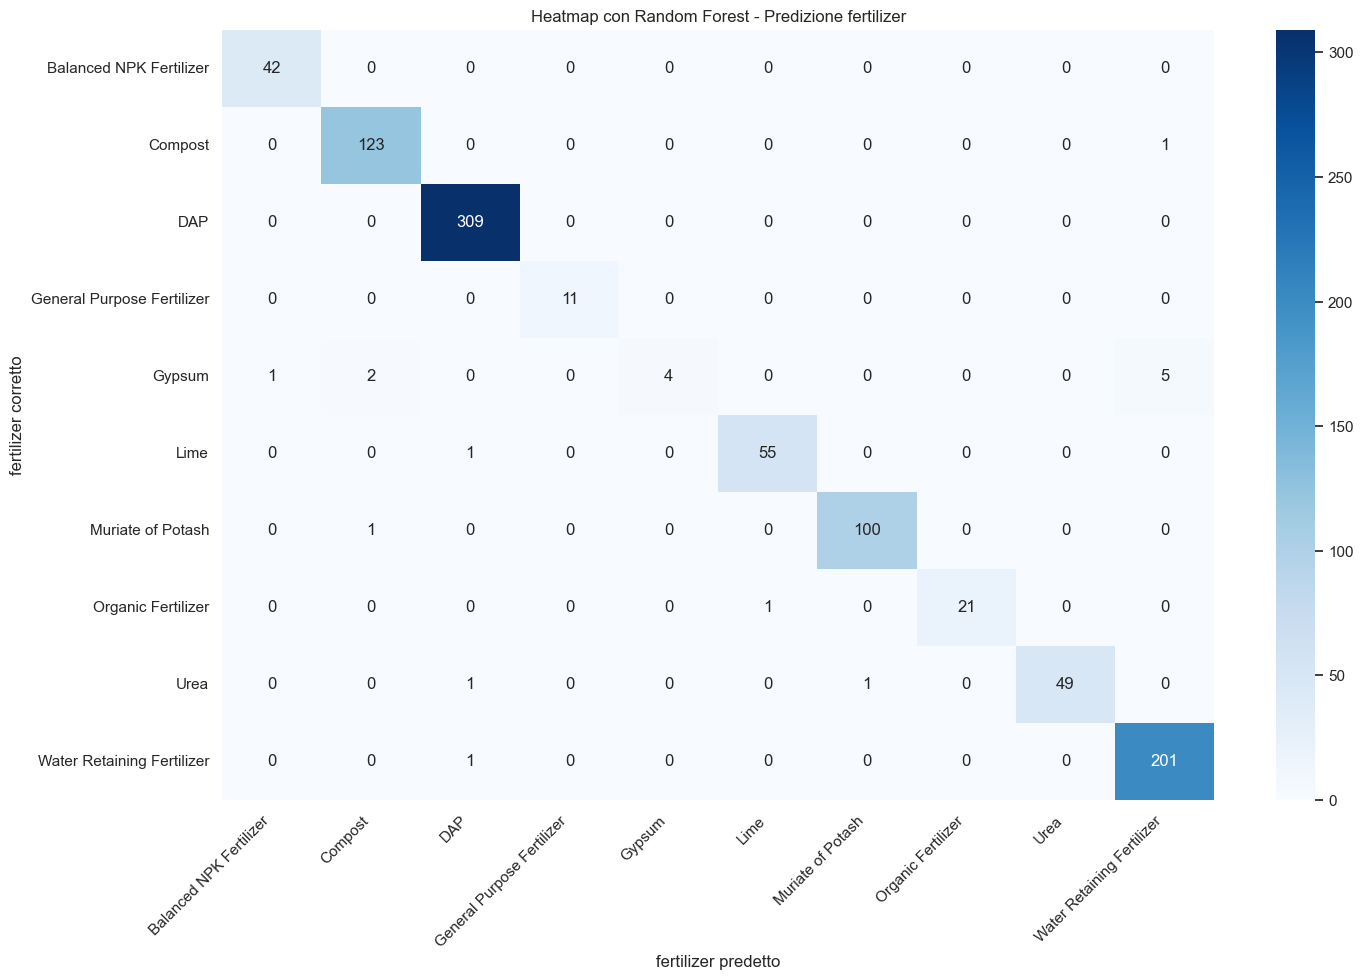

In [ ]:
rf_model = train_random_forest(X, y, "fertilizer")

### XGBoost

justin

# Interfaccia Web

In [ ]:
import joblib

rf_crop_model_name = 'rf-crop-model.pkl'
# joblib.dump(rf_model, rf_crop_model_name)